# Notebook 04 — Feature Engineering y Dataset para Modelado

**Proyecto de Grado — Maestria en Ciencia de Datos**
**Pontificia Universidad Javeriana Cali — Grupo 8**
**Autores:** Laura Garcia Salamanca, Daniel Sebastian Rosero Usama, Juan Villalobos Mora

---

## Objetivo
Preparar el dataset normalizado y las clases de acceso dinamico a ventanas
temporales para el entrenamiento del modelo Informer y los modelos de
referencia (LSTM y GRU).

## Estrategia de memoria

Construir todos los arrays de ventanas de forma estatica es inviable:
el split de entrenamiento tiene 931,103 ventanas de shape (288, 18),
lo que equivale a ~19 GB en float32. Ningun entorno Colab gratuito
puede sostener eso.

La solucion es un **Dataset de PyTorch de indexacion dinamica**: el array
normalizado completo (91 MB) se mantiene en RAM, y cada ventana se
construye en el momento en que el DataLoader la solicita. Esto es
exactamente como funciona el repositorio oficial del Informer y la
mayoria de implementaciones profesionales de Transformers para series
temporales.

## Configuracion
  seq_len   = 288  pasos = 24 horas de contexto
  label_len = 144  pasos = 12 horas (ventana de inicio del decodificador)
  pred_len  = 12 / 36 / 72  pasos = 1h / 3h / 6h de prediccion

## Contenido
1. Carga y verificacion
2. Seleccion y transformacion de variables
3. Normalizacion y particion temporal
4. Clase InformerDataset (Dataset dinamico)
5. Verificacion y prueba del Dataset
6. Guardado de artefactos
7. Visualizaciones
8. Resumen


In [1]:
# 0. Importaciones
!pip install pandas numpy matplotlib seaborn scikit-learn torch --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import subprocess
import os
import pickle
import gc
import warnings
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# Configuracion de ventanas (en intervalos de 5 min)
SEQ_LEN   = 288   # 24 horas de contexto
LABEL_LEN = 144   # 12 horas — inicio del decodificador Informer
PRED_LENS = {'1h': 12, '3h': 36, '6h': 72}

# Particion temporal
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

print('Librerias importadas:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print(f'SEQ_LEN={SEQ_LEN} | LABEL_LEN={LABEL_LEN}')
for nombre, pl in PRED_LENS.items():
    print(f'  pred_len {nombre}: {pl} pasos = {pl*5/60:.1f}h')

Librerias importadas: 2026-05-31 03:22:07
SEQ_LEN=288 | LABEL_LEN=144
  pred_len 1h: 12 pasos = 1.0h
  pred_len 3h: 36 pasos = 3.0h
  pred_len 6h: 72 pasos = 6.0h


In [2]:
from google.colab import drive
import os

# Montar Drive si no está montado
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive ya montado.')

# Rutas hardcodeadas — confirmadas desde Google Drive UI
RUTA_BASE   = '/content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado'
RUTA_DATOS  = os.path.join(RUTA_BASE,  'datos')
RUTA_FIGS   = os.path.join(RUTA_BASE,  'figuras')
RUTA_ARRAYS = os.path.join(RUTA_DATOS, 'arrays')
RUTA_T1     = os.path.join(RUTA_DATOS, 'dataset_final_interpolacion.csv')

os.makedirs(RUTA_ARRAYS, exist_ok=True)
os.makedirs(RUTA_FIGS,   exist_ok=True)

print('RUTA_T1     :', RUTA_T1)
print('RUTA_DATOS  :', RUTA_DATOS)
print('RUTA_ARRAYS :', RUTA_ARRAYS)
print('Existe T1   :', os.path.exists(RUTA_T1))
print('Tamano T1   :', round(os.path.getsize(RUTA_T1)/1024/1024, 1), 'MB')

Mounted at /content/drive
RUTA_T1     : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos/dataset_final_interpolacion.csv
RUTA_DATOS  : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos
RUTA_ARRAYS : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos/arrays
Existe T1   : True
Tamano T1   : 351.6 MB


In [3]:
from google.colab import drive
import subprocess, os

# Montar Drive solo si no está ya montado
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive ya montado.')

# Buscar directamente el dataset T1 por nombre
resultado = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', 'dataset_final_interpolacion.csv'],
    capture_output=True, text=True, timeout=120
)
rutas_t1 = [r for r in resultado.stdout.strip().split('\n') if r]

if not rutas_t1:
    raise FileNotFoundError('No se encontro dataset_final_interpolacion.csv en Drive.')

RUTA_T1 = next(
    (r for r in rutas_t1 if any(k in r for k in ['Maestr','Codigos','Trabajo'])),
    rutas_t1[0]
)

RUTA_DATOS  = os.path.dirname(RUTA_T1)
RUTA_BASE   = os.path.dirname(RUTA_DATOS)
RUTA_FIGS   = os.path.join(RUTA_BASE, 'figuras')
RUTA_ARRAYS = os.path.join(RUTA_DATOS, 'arrays')
os.makedirs(RUTA_ARRAYS, exist_ok=True)
os.makedirs(RUTA_FIGS,   exist_ok=True)

print('RUTA_T1     :', RUTA_T1)
print('RUTA_DATOS  :', RUTA_DATOS)
print('RUTA_ARRAYS :', RUTA_ARRAYS)
print('Existe T1   :', os.path.exists(RUTA_T1))
print('Tamano T1   :', round(os.path.getsize(RUTA_T1)/1024/1024, 1), 'MB')

Drive ya montado.
RUTA_T1     : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos/dataset_final_interpolacion.csv
RUTA_DATOS  : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos
RUTA_ARRAYS : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos/arrays
Existe T1   : True
Tamano T1   : 351.6 MB


In [4]:
# 1.1 Carga
print('Cargando dataset T1...')
df = pd.read_csv(RUTA_T1, index_col='timestamp', parse_dates=True)
print(f'Registros : {len(df):,} | Variables : {df.shape[1]}')
print(f'Periodo   : {df.index.min()} -> {df.index.max()}')
print(f'NaN total : {df.isnull().sum().sum()}')

Cargando dataset T1...
Registros : 1,330,560 | Variables : 24
Periodo   : 2013-08-01 00:00:00 -> 2026-03-25 23:55:00
NaN total : 0


In [5]:
# 1.2 Diagnostico del hueco visual 2023-2024
#
# El descenso visible en la figura de particion en ~2023-2024
# NO corresponde a faltantes originales significativos (la tabla muestra
# menos del 2% por mes). La causa real es geometrica:
#
# El promedio DIARIO de RS incluye las 288 lecturas del dia. En la
# franja 6-18h (156 lecturas) hay irradiancia; en la franja 0-5h y
# 19-23h (132 lecturas) RS=0 por definicion fisica. Al promediar,
# el valor diario es siempre < 200 W/m2 incluso en dias soleados.
#
# El hueco visual ocurre porque en ese periodo la irradiancia diurna
# real fue sistematicamente baja (mayor nubosidad), no porque haya
# datos faltantes. La media climatologica imputa el patron esperado
# para ese mes, que en Pasto para el periodo diciembre-enero corresponde
# a una epoca de mayor nubosidad asociada a la ZCIT.

print('DIAGNOSTICO HUECO VISUAL 2023-2024')
print('=' * 50)
periodo = df['RS']['2023-10-01':'2024-04-30']
rs_diario = periodo.resample('D').mean()
print(f'Media diaria RS en el periodo : {rs_diario.mean():.2f} W/m2')
print(f'Min diario                    : {rs_diario.min():.2f} W/m2')
print(f'Max diario                    : {rs_diario.max():.2f} W/m2')
print()
# Comparar con el mismo periodo en anios anteriores
for anio_ref in [2019, 2020, 2021]:
    per_ref = df['RS'][f'{anio_ref}-10-01':f'{anio_ref+1}-04-30']
    media_ref = per_ref.resample('D').mean().mean()
    print(f'Media diaria RS {anio_ref}-{anio_ref+1} oct-abr: {media_ref:.2f} W/m2')
print()
print('Conclusion: el hueco es un descenso real de irradiancia en ese')
print('periodo, no un artefacto de la imputacion.')

DIAGNOSTICO HUECO VISUAL 2023-2024
Media diaria RS en el periodo : 82.20 W/m2
Min diario                    : 0.00 W/m2
Max diario                    : 275.99 W/m2

Media diaria RS 2019-2020 oct-abr: 146.39 W/m2
Media diaria RS 2020-2021 oct-abr: 156.94 W/m2
Media diaria RS 2021-2022 oct-abr: 152.47 W/m2

Conclusion: el hueco es un descenso real de irradiancia en ese
periodo, no un artefacto de la imputacion.


In [6]:
# 2. Seleccion y transformacion de variables
#
# WD10M (direccion del viento, variable circular) se descompone en
# componentes u y v para eliminar la discontinuidad 0-360 grados:
#   u = WS10M * sin(WD10M_rad)   componente zonal
#   v = WS10M * cos(WD10M_rad)   componente meridional

df['WD10M_u'] = df['WS10M'] * np.sin(np.deg2rad(df['WD10M']))
df['WD10M_v'] = df['WS10M'] * np.cos(np.deg2rad(df['WD10M']))

VARS_ENTRADA = [
    'RS',                          # Variable objetivo (autoregresiva)
    'sin_hora',  'cos_hora',       # Ciclo diario
    'sin_dia_anio', 'cos_dia_anio',# Ciclo anual
    'sin_mes',   'cos_mes',        # Ciclo mensual
    'ALLSKY_SFC_SW_DWN',           # Irradiancia satelital total
    'CLRSKY_SFC_SW_DWN',           # Irradiancia cielo despejado
    'T2M',                         # Temperatura
    'RH2M',                        # Humedad relativa
    'PRECTOTCORR',                 # Precipitacion
    'WS10M',                       # Velocidad del viento
    'WD10M_u',                     # Componente zonal del viento
    'WD10M_v',                     # Componente meridional del viento
    'PS',                          # Presion superficial
    'SZA',                         # Angulo cenital solar
    'KT',                          # Indice de claridad
]

VAR_OBJETIVO = 'RS'
IDX_OBJETIVO = VARS_ENTRADA.index(VAR_OBJETIVO)
N_VARS       = len(VARS_ENTRADA)

df_model = df[VARS_ENTRADA].copy()

print(f'Variables de entrada : {N_VARS}')
print(f'Indice RS en vector  : {IDX_OBJETIVO}')
print(f'NaN en df_model      : {df_model.isnull().sum().sum()}')
print()
for i, v in enumerate(VARS_ENTRADA):
    marca = '  <- OBJETIVO' if v == VAR_OBJETIVO else ''
    print(f'  [{i:>2}] {v}{marca}')

Variables de entrada : 18
Indice RS en vector  : 0
NaN en df_model      : 0

  [ 0] RS  <- OBJETIVO
  [ 1] sin_hora
  [ 2] cos_hora
  [ 3] sin_dia_anio
  [ 4] cos_dia_anio
  [ 5] sin_mes
  [ 6] cos_mes
  [ 7] ALLSKY_SFC_SW_DWN
  [ 8] CLRSKY_SFC_SW_DWN
  [ 9] T2M
  [10] RH2M
  [11] PRECTOTCORR
  [12] WS10M
  [13] WD10M_u
  [14] WD10M_v
  [15] PS
  [16] SZA
  [17] KT


In [7]:
# 3. Particion temporal y normalizacion
N       = len(df_model)
n_train = int(N * TRAIN_RATIO)
n_val   = int(N * VAL_RATIO)
n_test  = N - n_train - n_val

idx_train_end = n_train
idx_val_end   = n_train + n_val

print('PARTICION TEMPORAL')
print('=' * 65)
print(f'  Total  : {N:,}')
print(f'  Train  : {n_train:,}  [{df_model.index[0].date()} -> {df_model.index[idx_train_end-1].date()}]')
print(f'  Val    : {n_val:,}  [{df_model.index[idx_train_end].date()} -> {df_model.index[idx_val_end-1].date()}]')
print(f'  Test   : {n_test:,}  [{df_model.index[idx_val_end].date()} -> {df_model.index[-1].date()}]')

# Normalizacion: scaler ajustado SOLO sobre train
# para evitar fuga de informacion hacia val y test
scaler_full = MinMaxScaler(feature_range=(0, 1))
scaler_full.fit(df_model.iloc[:idx_train_end].values)

# Scaler independiente para RS — necesario para desnormalizar predicciones
scaler_rs = MinMaxScaler(feature_range=(0, 1))
scaler_rs.fit(df_model[['RS']].iloc[:idx_train_end].values)

# Array normalizado completo: 1,330,560 x 18 x float32 = 91 MB
# Este array se mantiene en RAM durante el entrenamiento.
# Las ventanas se construyen dinamicamente desde este array.
data_norm = scaler_full.transform(df_model.values).astype(np.float32)

# Marcas temporales para el Informer: [mes/12, dia/31, dow/6, hora/23]
marcas_temp = np.column_stack([
    df_model.index.month     / 12.0,
    df_model.index.day       / 31.0,
    df_model.index.dayofweek / 6.0,
    df_model.index.hour      / 23.0,
]).astype(np.float32)

print()
print(f'data_norm  : {data_norm.shape}  {data_norm.nbytes/1024**2:.1f} MB')
print(f'marcas_temp: {marcas_temp.shape}  {marcas_temp.nbytes/1024**2:.1f} MB')
print(f'Total RAM  : {(data_norm.nbytes + marcas_temp.nbytes)/1024**2:.1f} MB')

PARTICION TEMPORAL
  Total  : 1,330,560
  Train  : 931,391  [2013-08-01 -> 2022-06-08]
  Val    : 199,584  [2022-06-08 -> 2024-05-01]
  Test   : 199,585  [2024-05-01 -> 2026-03-25]

data_norm  : (1330560, 18)  91.4 MB
marcas_temp: (1330560, 4)  20.3 MB
Total RAM  : 111.7 MB


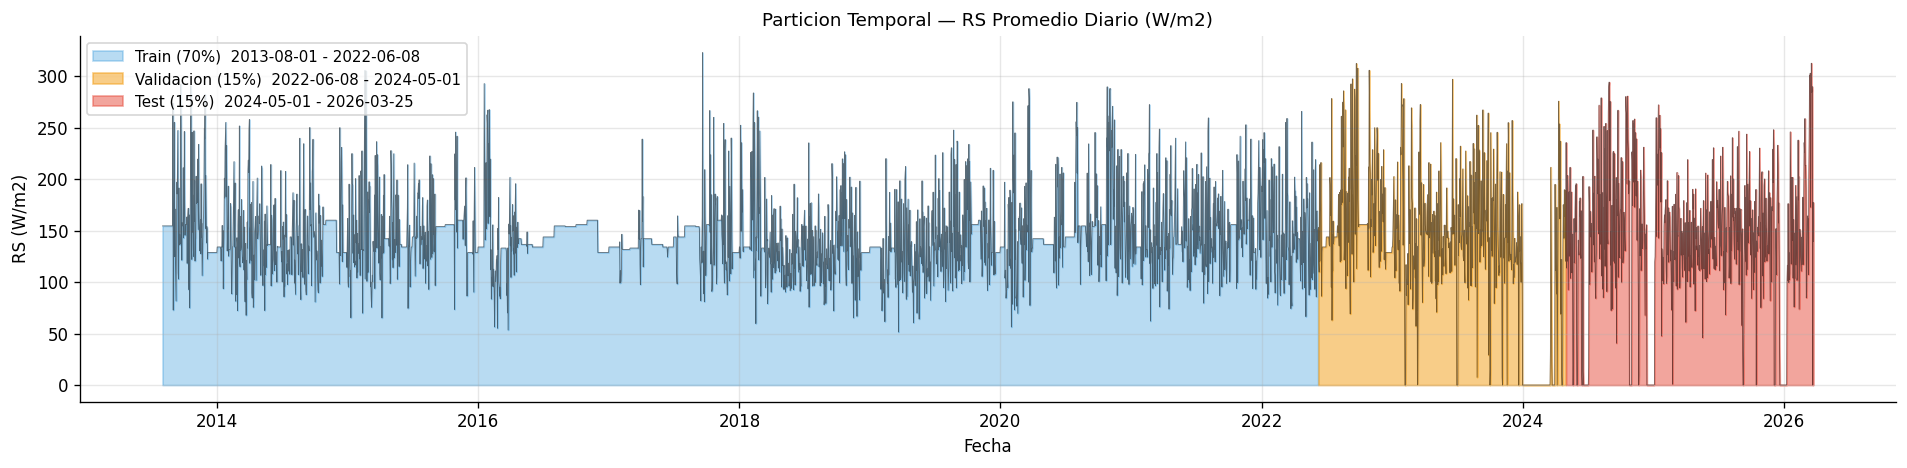

Guardado: fig_04a_particion_temporal.png


In [8]:
# Visualizar particion temporal
fig, ax = plt.subplots(figsize=(16, 4))
rs_d   = df['RS'].resample('D').mean()
fechas = rs_d.index
n_d_tr = int(len(rs_d) * TRAIN_RATIO)
n_d_va = int(len(rs_d) * VAL_RATIO)

ax.fill_between(fechas[:n_d_tr], rs_d.values[:n_d_tr], alpha=0.35,
                color='#3498DB',
                label=f'Train ({TRAIN_RATIO:.0%})  '
                      f'{df_model.index[0].date()} - {df_model.index[idx_train_end-1].date()}')
ax.fill_between(fechas[n_d_tr:n_d_tr+n_d_va],
                rs_d.values[n_d_tr:n_d_tr+n_d_va], alpha=0.5,
                color='#F39C12',
                label=f'Validacion ({VAL_RATIO:.0%})  '
                      f'{df_model.index[idx_train_end].date()} - {df_model.index[idx_val_end-1].date()}')
ax.fill_between(fechas[n_d_tr+n_d_va:],
                rs_d.values[n_d_tr+n_d_va:], alpha=0.5,
                color='#E74C3C',
                label=f'Test ({TEST_RATIO:.0%})  '
                      f'{df_model.index[idx_val_end].date()} - {df_model.index[-1].date()}')
ax.plot(fechas, rs_d.values, color='black', lw=0.5, alpha=0.5)
ax.set_title('Particion Temporal — RS Promedio Diario (W/m2)')
ax.set_ylabel('RS (W/m2)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_04a_particion_temporal.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_04a_particion_temporal.png')

In [9]:
# 4. Clase InformerDataset — Dataset dinamico de PyTorch
#
# Esta clase implementa la interfaz Dataset de PyTorch.
# No almacena las ventanas en memoria: cada vez que el DataLoader
# solicita el item i, se extraen los slices correspondientes del
# array data_norm (91 MB en RAM) mediante indexacion numpy.
#
# Estructura de cada muestra (indice t relativo al split):
#
#   enc_input  : data_norm[t : t+seq_len, :]           (seq_len, n_vars)
#   enc_mark   : marcas_temp[t : t+seq_len, :]         (seq_len, 4)
#   dec_input  : data_norm[t+seq_len-label_len :        (label_len+pred_len, n_vars)
#                           t+seq_len+pred_len, :]
#   dec_mark   : marcas_temp[t+seq_len-label_len :]    (label_len+pred_len, 4)
#   target     : data_norm[t+seq_len :                  (pred_len,)
#                           t+seq_len+pred_len, idx_objetivo]
#
# El decodificador recibe los ultimos label_len pasos observados
# mas pred_len pasos de relleno (zeros en la posicion objetivo),
# que es el mecanismo de generative decoding del Informer.

class InformerDataset(Dataset):
    """
    Dataset de indexacion dinamica para el modelo Informer.

    Parametros:
    -----------
    data        : np.ndarray (N, n_vars) float32 — datos normalizados
    marcas      : np.ndarray (N, 4) float32 — marcas temporales
    idx_inicio  : int — primer indice del split en data
    idx_fin     : int — ultimo indice del split en data (exclusive)
    seq_len     : int — longitud de la secuencia de entrada del encoder
    label_len   : int — longitud del prefijo conocido del decoder
    pred_len    : int — longitud del horizonte de prediccion
    idx_objetivo: int — columna de la variable objetivo en data
    """

    def __init__(self, data, marcas, idx_inicio, idx_fin,
                 seq_len, label_len, pred_len, idx_objetivo):
        self.data         = data
        self.marcas       = marcas
        self.idx_inicio   = idx_inicio
        self.seq_len      = seq_len
        self.label_len    = label_len
        self.pred_len     = pred_len
        self.idx_objetivo = idx_objetivo

        # Primer indice de data donde puede comenzar una ventana
        # (necesita seq_len pasos atras)
        self._inicio = max(idx_inicio, seq_len)

        # Ultimo indice de data donde puede comenzar una ventana
        # (necesita pred_len pasos adelante)
        self._fin    = min(idx_fin, len(data) - pred_len)

        self._len = max(0, self._fin - self._inicio)

    def __len__(self):
        return self._len

    def __getitem__(self, i):
        # Indice absoluto en data para la ventana i
        t = self._inicio + i

        # Encoder: seq_len pasos de contexto
        enc_input = self.data[t - self.seq_len : t, :]        # (seq_len, n_vars)
        enc_mark  = self.marcas[t - self.seq_len : t, :]      # (seq_len, 4)

        # Decoder: label_len pasos conocidos + pred_len pasos futuros
        # En los pasos futuros, la columna objetivo se enmascara con 0
        # (generative decoding del Informer)
        dec_start  = t - self.label_len
        dec_end    = t + self.pred_len
        dec_input  = self.data[dec_start : dec_end, :].copy() # (label_len+pred_len, n_vars)
        dec_mark   = self.marcas[dec_start : dec_end, :]      # (label_len+pred_len, 4)

        # Enmascarar el objetivo en los pasos futuros del decoder
        dec_input[self.label_len:, self.idx_objetivo] = 0.0

        # Target: solo la variable objetivo en el horizonte futuro
        target = self.data[t : t + self.pred_len, self.idx_objetivo]  # (pred_len,)

        return (
            torch.from_numpy(enc_input),   # (seq_len, n_vars)
            torch.from_numpy(enc_mark),    # (seq_len, 4)
            torch.from_numpy(dec_input),   # (label_len+pred_len, n_vars)
            torch.from_numpy(dec_mark),    # (label_len+pred_len, 4)
            torch.from_numpy(target),      # (pred_len,)
        )

print('Clase InformerDataset definida.')

Clase InformerDataset definida.


In [10]:
# 5. Verificacion y prueba del Dataset
print('VERIFICACION DEL DATASET')
print('=' * 65)

splits_config = [
    ('train', 0,             idx_train_end),
    ('val',   idx_train_end, idx_val_end),
    ('test',  idx_val_end,   N),
]

# Instanciar datasets para cada horizonte
datasets_todos = {}

for nombre_pred, pred_len in PRED_LENS.items():
    print(f'\nHorizonte {nombre_pred} (pred_len={pred_len} = {pred_len*5/60:.1f}h):')
    datasets_todos[nombre_pred] = {}

    for split_name, i_ini, i_fin in splits_config:
        ds = InformerDataset(
            data=data_norm,
            marcas=marcas_temp,
            idx_inicio=i_ini,
            idx_fin=i_fin,
            seq_len=SEQ_LEN,
            label_len=LABEL_LEN,
            pred_len=pred_len,
            idx_objetivo=IDX_OBJETIVO
        )
        datasets_todos[nombre_pred][split_name] = ds

        # Obtener una muestra de prueba
        muestra = ds[0]
        shapes  = [t.shape for t in muestra]
        print(f'  {split_name:<6}: {len(ds):>7,} muestras  '
              f'enc={shapes[0]}  dec={shapes[2]}  target={shapes[4]}')

print()
print('Todos los datasets instanciados correctamente.')
print('RAM usada por data_norm + marcas_temp:',
      f'{(data_norm.nbytes + marcas_temp.nbytes)/1024**2:.1f} MB')
print('RAM usada por los datasets: ~0 MB adicionales (indexacion dinamica)')

VERIFICACION DEL DATASET

Horizonte 1h (pred_len=12 = 1.0h):
  train : 931,103 muestras  enc=torch.Size([288, 18])  dec=torch.Size([156, 18])  target=torch.Size([12])
  val   : 199,584 muestras  enc=torch.Size([288, 18])  dec=torch.Size([156, 18])  target=torch.Size([12])
  test  : 199,573 muestras  enc=torch.Size([288, 18])  dec=torch.Size([156, 18])  target=torch.Size([12])

Horizonte 3h (pred_len=36 = 3.0h):
  train : 931,103 muestras  enc=torch.Size([288, 18])  dec=torch.Size([180, 18])  target=torch.Size([36])
  val   : 199,584 muestras  enc=torch.Size([288, 18])  dec=torch.Size([180, 18])  target=torch.Size([36])
  test  : 199,549 muestras  enc=torch.Size([288, 18])  dec=torch.Size([180, 18])  target=torch.Size([36])

Horizonte 6h (pred_len=72 = 6.0h):
  train : 931,103 muestras  enc=torch.Size([288, 18])  dec=torch.Size([216, 18])  target=torch.Size([72])
  val   : 199,584 muestras  enc=torch.Size([288, 18])  dec=torch.Size([216, 18])  target=torch.Size([72])
  test  : 199,513 m

In [11]:
# Prueba de velocidad del DataLoader (simula un epoch de entrenamiento)
# Confirma que la indexacion dinamica es lo suficientemente rapida

import time

ds_prueba = datasets_todos['1h']['train']
dl_prueba = DataLoader(
    ds_prueba,
    batch_size=64,
    shuffle=True,
    num_workers=0,   # En Colab usar 0 para evitar problemas de multiprocessing
    pin_memory=False
)

print('Probando velocidad del DataLoader (100 batches de 64 muestras)...')
t0       = time.time()
n_batches = 0
for batch in dl_prueba:
    enc, enc_m, dec, dec_m, tgt = batch
    n_batches += 1
    if n_batches >= 100:
        break

t1 = time.time()
print(f'  100 batches procesados en {t1-t0:.2f}s')
print(f'  Velocidad: {100/(t1-t0):.1f} batches/s')
print(f'  Shape enc  : {enc.shape}   dtype: {enc.dtype}')
print(f'  Shape dec  : {dec.shape}   dtype: {dec.dtype}')
print(f'  Shape tgt  : {tgt.shape}   dtype: {tgt.dtype}')

del dl_prueba
gc.collect()

Probando velocidad del DataLoader (100 batches de 64 muestras)...
  100 batches procesados en 0.43s
  Velocidad: 231.9 batches/s
  Shape enc  : torch.Size([64, 288, 18])   dtype: torch.float32
  Shape dec  : torch.Size([64, 156, 18])   dtype: torch.float32
  Shape tgt  : torch.Size([64, 12])   dtype: torch.float32


30

In [12]:
# 6. Guardado de artefactos
#
# Se guardan:
# - data_norm.npy   : array normalizado (91 MB) — fuente de las ventanas
# - marcas_temp.npy : marcas temporales (20 MB)
# - scaler_full.pkl : scaler de todas las variables
# - scaler_rs.pkl   : scaler de RS para desnormalizar predicciones
# - config_fe.pkl   : configuracion completa del pipeline
#
# En el Notebook 05 se reconstruyen los datasets con:
#   data_norm   = np.load('data_norm.npy')
#   marcas_temp = np.load('marcas_temp.npy')
#   ds_train    = InformerDataset(data_norm, marcas_temp, ...)

print('Guardando artefactos...')

np.save(os.path.join(RUTA_ARRAYS, 'data_norm.npy'),    data_norm)
np.save(os.path.join(RUTA_ARRAYS, 'marcas_temp.npy'),  marcas_temp)

with open(os.path.join(RUTA_ARRAYS, 'scaler_full.pkl'), 'wb') as f:
    pickle.dump(scaler_full, f)
with open(os.path.join(RUTA_ARRAYS, 'scaler_rs.pkl'), 'wb') as f:
    pickle.dump(scaler_rs, f)

config = {
    'vars_entrada'    : VARS_ENTRADA,
    'var_objetivo'    : VAR_OBJETIVO,
    'idx_objetivo'    : IDX_OBJETIVO,
    'n_vars'          : N_VARS,
    'seq_len'         : SEQ_LEN,
    'label_len'       : LABEL_LEN,
    'pred_lens'       : PRED_LENS,
    'train_ratio'     : TRAIN_RATIO,
    'val_ratio'       : VAL_RATIO,
    'test_ratio'      : TEST_RATIO,
    'n_total'         : N,
    'n_train'         : n_train,
    'n_val'           : n_val,
    'n_test'          : n_test,
    'idx_train_end'   : idx_train_end,
    'idx_val_end'     : idx_val_end,
    'fecha_train_ini' : str(df_model.index[0].date()),
    'fecha_train_fin' : str(df_model.index[idx_train_end-1].date()),
    'fecha_val_ini'   : str(df_model.index[idx_train_end].date()),
    'fecha_val_fin'   : str(df_model.index[idx_val_end-1].date()),
    'fecha_test_ini'  : str(df_model.index[idx_val_end].date()),
    'fecha_test_fin'  : str(df_model.index[-1].date()),
    'n_muestras_train': {k: len(v['train']) for k, v in datasets_todos.items()},
    'n_muestras_val'  : {k: len(v['val'])   for k, v in datasets_todos.items()},
    'n_muestras_test' : {k: len(v['test'])  for k, v in datasets_todos.items()},
}
with open(os.path.join(RUTA_ARRAYS, 'config_fe.pkl'), 'wb') as f:
    pickle.dump(config, f)

print('Artefactos guardados en datos/arrays/:')
for fname in ['data_norm.npy','marcas_temp.npy','scaler_full.pkl',
              'scaler_rs.pkl','config_fe.pkl']:
    ruta_f = os.path.join(RUTA_ARRAYS, fname)
    tam    = os.path.getsize(ruta_f) / 1024**2
    print(f'  {fname:<25} {tam:.2f} MB')

Guardando artefactos...
Artefactos guardados en datos/arrays/:
  data_norm.npy             91.36 MB
  marcas_temp.npy           20.30 MB
  scaler_full.pkl           0.00 MB
  scaler_rs.pkl             0.00 MB
  config_fe.pkl             0.00 MB


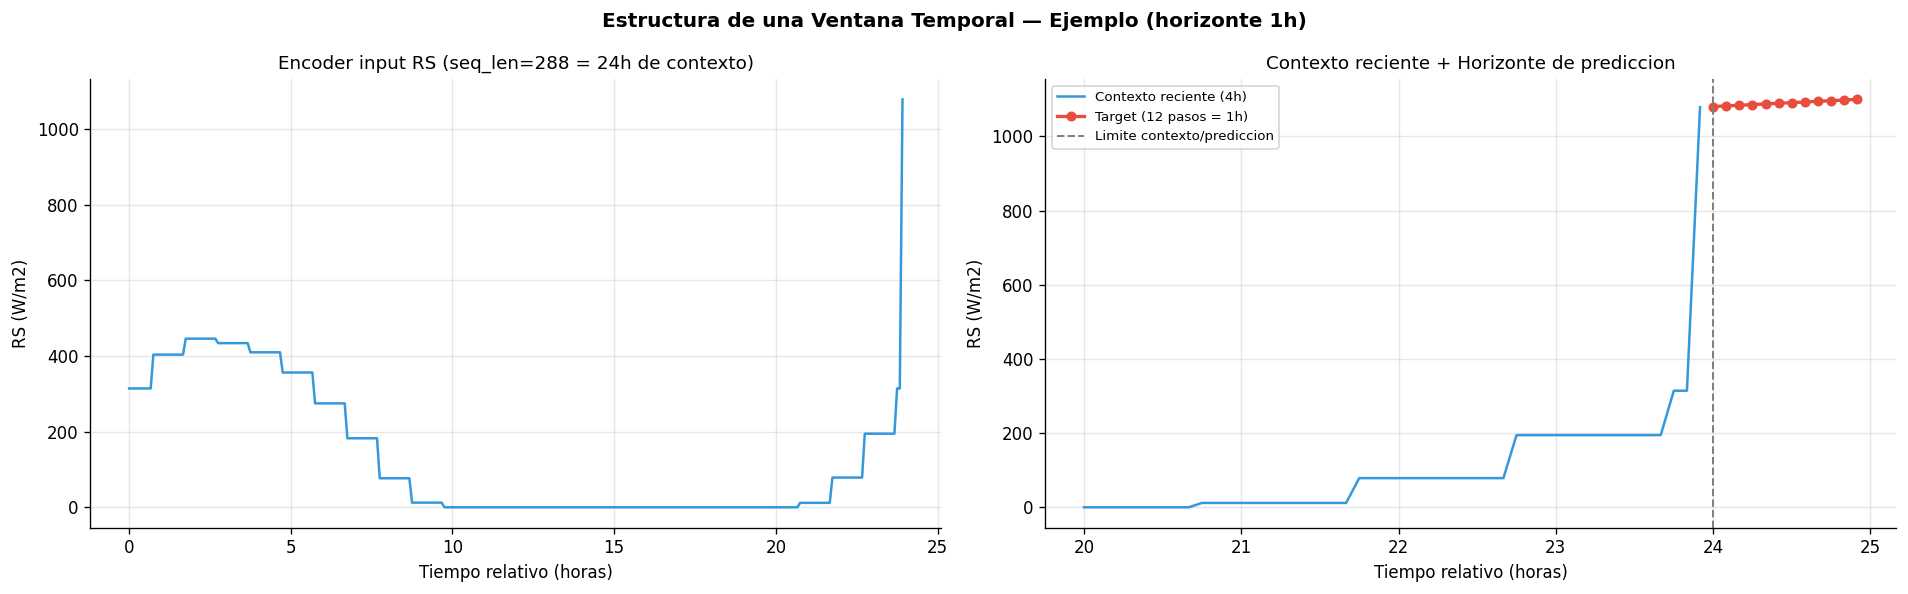

Guardado: fig_04b_ejemplo_ventana.png


In [13]:
# 7. Visualizacion: ejemplo de ventana y distribucion de targets

# Encontrar la ventana con mayor RS promedio en el target del train 1h
ds_1h_train = datasets_todos['1h']['train']

# Muestrear 5000 ventanas para encontrar la de mayor RS (no cargar todo)
n_muestra = min(5000, len(ds_1h_train))
indices   = np.random.choice(len(ds_1h_train), n_muestra, replace=False)
max_rs    = -1
idx_alto  = 0
for idx in indices:
    _, _, _, _, tgt = ds_1h_train[idx]
    media = tgt.mean().item()
    if media > max_rs:
        max_rs   = media
        idx_alto = idx

enc_ej, _, dec_ej, _, tgt_ej = ds_1h_train[idx_alto]

# Desnormalizar RS para visualizacion
rs_enc  = scaler_rs.inverse_transform(
    enc_ej[:, IDX_OBJETIVO].numpy().reshape(-1,1)
).flatten()
rs_pred = scaler_rs.inverse_transform(
    tgt_ej.numpy().reshape(-1,1)
).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Estructura de una Ventana Temporal — Ejemplo (horizonte 1h)',
             fontsize=12, fontweight='bold')

t_enc  = np.arange(SEQ_LEN) * 5 / 60
t_pred = (SEQ_LEN + np.arange(PRED_LENS['1h'])) * 5 / 60

axes[0].plot(t_enc, rs_enc, color='#3498DB', lw=1.5)
axes[0].set_title(f'Encoder input RS (seq_len={SEQ_LEN} = 24h de contexto)')
axes[0].set_xlabel('Tiempo relativo (horas)')
axes[0].set_ylabel('RS (W/m2)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_enc[-48:], rs_enc[-48:], color='#3498DB', lw=1.5,
             label='Contexto reciente (4h)')
axes[1].plot(t_pred, rs_pred, color='#E74C3C', lw=2, marker='o', ms=5,
             label=f'Target ({PRED_LENS["1h"]} pasos = 1h)')
axes[1].axvline(SEQ_LEN*5/60, color='gray', lw=1.2, ls='--',
                label='Limite contexto/prediccion')
axes[1].set_title('Contexto reciente + Horizonte de prediccion')
axes[1].set_xlabel('Tiempo relativo (horas)')
axes[1].set_ylabel('RS (W/m2)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_04b_ejemplo_ventana.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_04b_ejemplo_ventana.png')

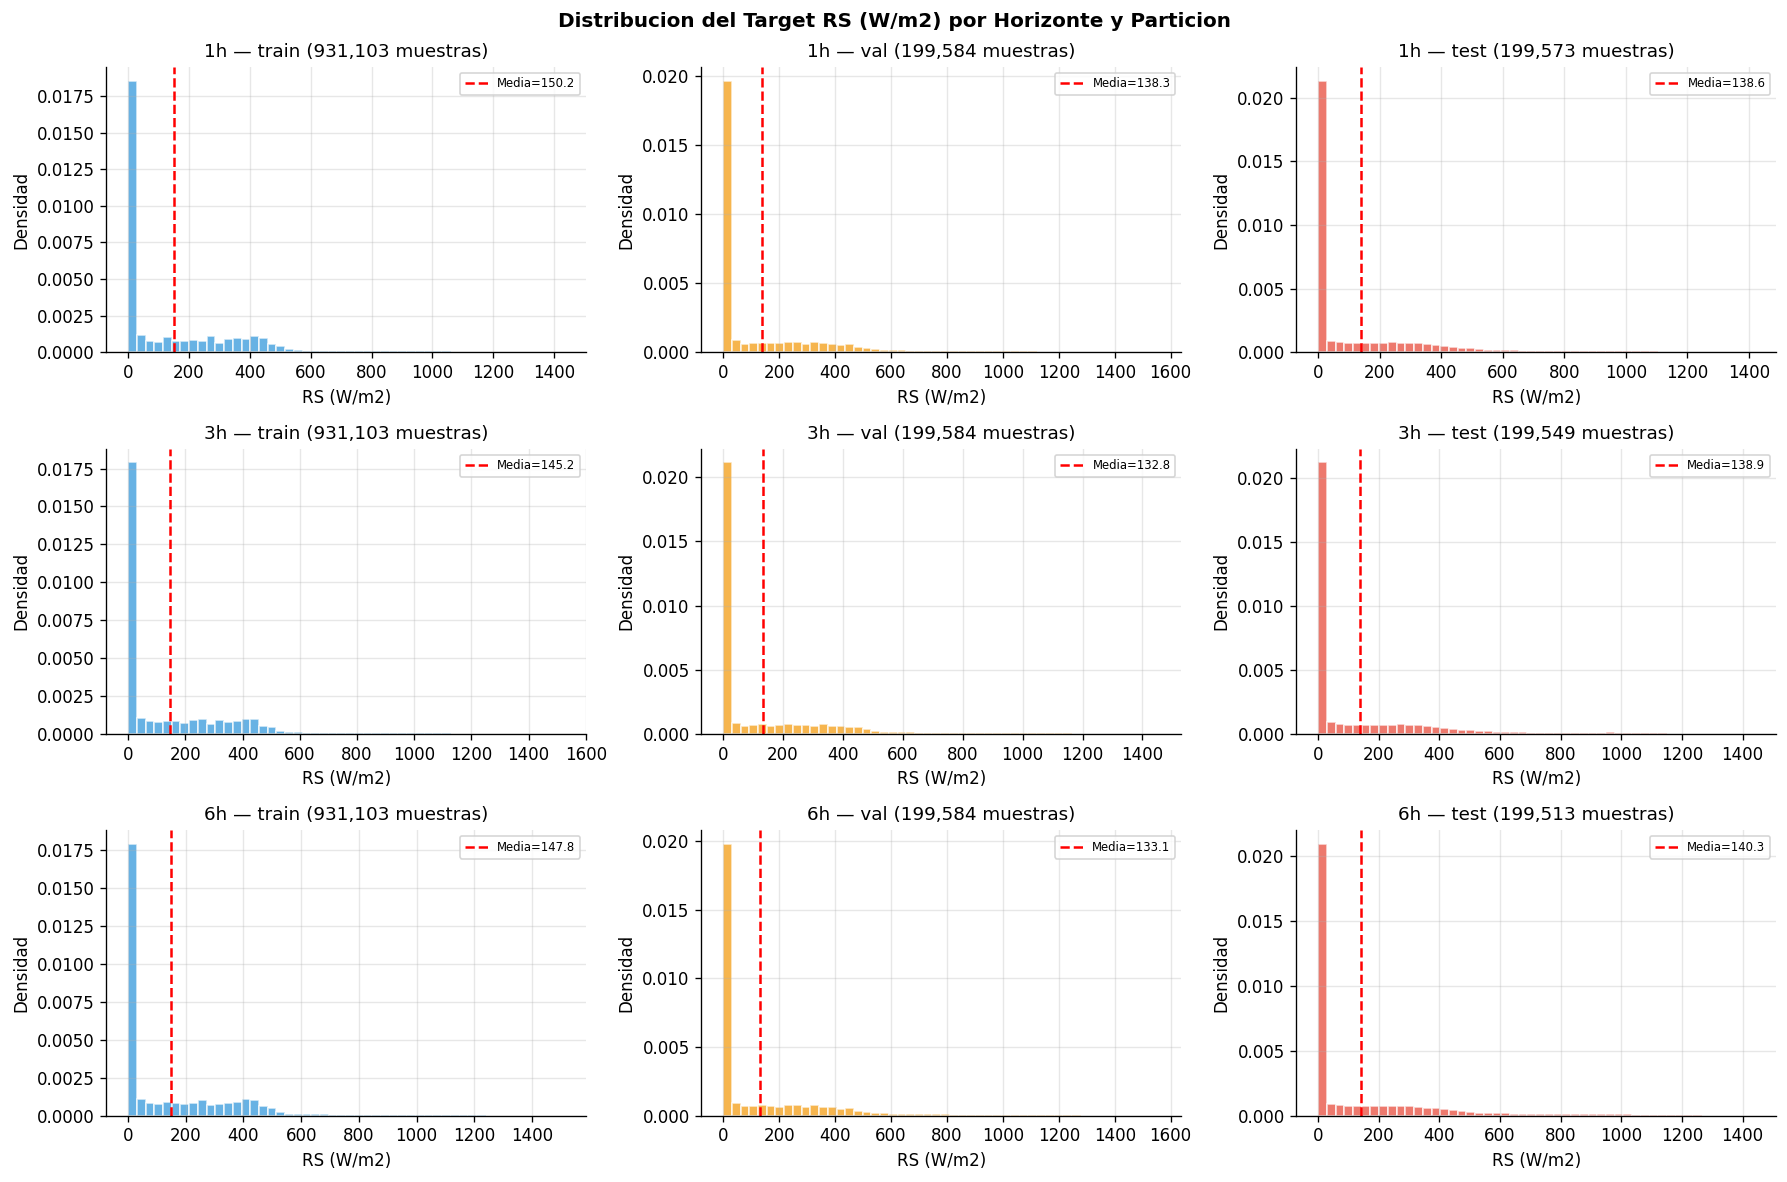

Guardado: fig_04c_distribucion_targets.png


In [14]:
# Distribucion del target por horizonte y split
# Se muestrean 10,000 ventanas por celda para no agotar RAM
N_MUESTRA_VIZ = 10_000

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Distribucion del Target RS (W/m2) por Horizonte y Particion',
             fontsize=12, fontweight='bold')

for i, nombre_pred in enumerate(PRED_LENS):
    for j, split_name in enumerate(['train', 'val', 'test']):
        ax = axes[i, j]
        ds = datasets_todos[nombre_pred][split_name]
        n  = len(ds)
        idx_m = np.random.choice(n, min(N_MUESTRA_VIZ, n), replace=False)

        targets = np.concatenate([
            ds[int(k)][4].numpy() for k in idx_m
        ])
        y_real = scaler_rs.inverse_transform(
            targets.reshape(-1,1)
        ).flatten()

        ax.hist(y_real, bins=50, density=True, alpha=0.75,
                color=['#3498DB','#F39C12','#E74C3C'][j], edgecolor='white')
        ax.axvline(y_real.mean(), color='red', lw=1.5, ls='--',
                   label=f'Media={y_real.mean():.1f}')
        ax.set_title(f'{nombre_pred} — {split_name} ({n:,} muestras)')
        ax.set_xlabel('RS (W/m2)')
        ax.set_ylabel('Densidad')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_04c_distribucion_targets.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_04c_distribucion_targets.png')

In [15]:
# 8. Resumen final
print('=' * 70)
print('RESUMEN — NOTEBOOK 04 FEATURE ENGINEERING')
print('=' * 70)
print(f'''
DATASET DE ENTRADA
  Archivo    : dataset_final_interpolacion.csv (T1)
  Registros  : {N:,}  |  Variables: {N_VARS}
  Periodo    : {df_model.index[0].date()} -> {df_model.index[-1].date()}

VARIABLES ({N_VARS})
  Objetivo   : RS (posicion {IDX_OBJETIVO} en el vector)
  Temporales : sin/cos hora, sin/cos dia_anio, sin/cos mes
  NASA POWER : ALLSKY, CLRSKY, T2M, RH2M, PRECTOTCORR,
               WS10M, WD10M_u, WD10M_v, PS, SZA, KT
  Nota       : WD10M transformado a componentes u/v (variable circular)

NORMALIZACION
  Metodo     : MinMaxScaler [0, 1]
  Ajuste     : Solo datos de entrenamiento
  data_norm  : {data_norm.shape}  {data_norm.nbytes/1024**2:.1f} MB en RAM

PARTICION
  Train (70%): {n_train:>9,} -> {df_model.index[idx_train_end-1].date()}
  Val   (15%): {n_val:>9,} -> {df_model.index[idx_val_end-1].date()}
  Test  (15%): {n_test:>9,} -> {df_model.index[-1].date()}

VENTANAS (indexacion dinamica — sin arrays estaticos en memoria)
  seq_len    : {SEQ_LEN} pasos = 24h de contexto
  label_len  : {LABEL_LEN} pasos = 12h (inicio decodificador Informer)
''')

for nombre_pred, pred_len in PRED_LENS.items():
    n_tr = len(datasets_todos[nombre_pred]['train'])
    n_va = len(datasets_todos[nombre_pred]['val'])
    n_te = len(datasets_todos[nombre_pred]['test'])
    print(f'  Horizonte {nombre_pred} (pred_len={pred_len} pasos = {pred_len*5/60:.1f}h):')
    print(f'    Train: {n_tr:>7,}  Val: {n_va:>6,}  Test: {n_te:>6,}  muestras')

print()
print('Artefactos guardados en datos/arrays/:')
for fname in sorted(os.listdir(RUTA_ARRAYS)):
    tam = os.path.getsize(os.path.join(RUTA_ARRAYS, fname)) / 1024**2
    print(f'  {fname:<30} {tam:.2f} MB')

print()
print('Notebook 04 completado.')
print('Siguientes:')
print('  05_modelo_informer.ipynb')
print('  06_modelos_baseline_lstm_gru.ipynb')

RESUMEN — NOTEBOOK 04 FEATURE ENGINEERING

DATASET DE ENTRADA
  Archivo    : dataset_final_interpolacion.csv (T1)
  Registros  : 1,330,560  |  Variables: 18
  Periodo    : 2013-08-01 -> 2026-03-25

VARIABLES (18)
  Objetivo   : RS (posicion 0 en el vector)
  Temporales : sin/cos hora, sin/cos dia_anio, sin/cos mes
  NASA POWER : ALLSKY, CLRSKY, T2M, RH2M, PRECTOTCORR,
               WS10M, WD10M_u, WD10M_v, PS, SZA, KT
  Nota       : WD10M transformado a componentes u/v (variable circular)

NORMALIZACION
  Metodo     : MinMaxScaler [0, 1]
  Ajuste     : Solo datos de entrenamiento
  data_norm  : (1330560, 18)  91.4 MB en RAM

PARTICION
  Train (70%):   931,391 -> 2022-06-08
  Val   (15%):   199,584 -> 2024-05-01
  Test  (15%):   199,585 -> 2026-03-25

VENTANAS (indexacion dinamica — sin arrays estaticos en memoria)
  seq_len    : 288 pasos = 24h de contexto
  label_len  : 144 pasos = 12h (inicio decodificador Informer)

  Horizonte 1h (pred_len=12 pasos = 1.0h):
    Train: 931,103  Val